<a href="https://colab.research.google.com/github/lsswiety/Exploring-GAN-Variants-for-Balancing-Imbalanced-Datasets/blob/main/GAN_Project_Laya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Setup and Data Loading
**Objective:** Load the MNIST dataset and create a synthetic imbalance.

We simulate a real-world problem by reducing the number of samples for **Digit 0** to only **10%**, making it a minority class that needs augmentation.

Using device: cpu


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.93MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 160kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.34MB/s]
/tmp/ipython-input-3273192964.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted(class_counts.keys()), y=[class_counts[k] for k in sorted(class_counts.keys())], palette="viridis")


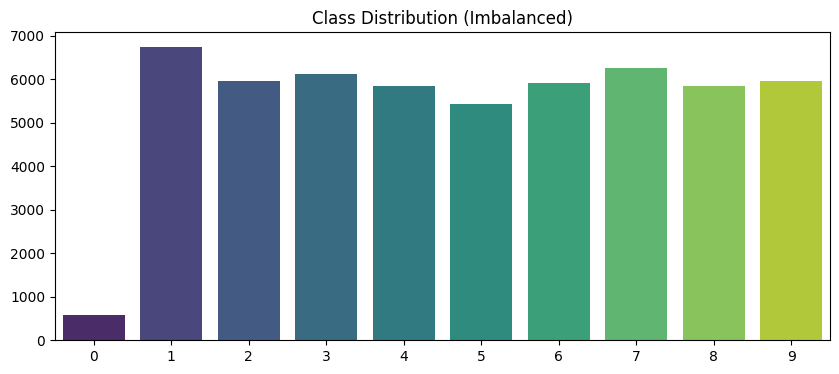

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import MNIST
from torchvision import transforms
from collections import Counter
from sklearn.metrics import classification_report, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Load Data & Create Imbalance
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Normalize inputs to [-1, 1]
])

train_dataset = MNIST(root="data", train=True, download=True, transform=transform)
test_dataset = MNIST(root="data", train=False, download=True, transform=transform)

X_train = train_dataset.data
y_train = train_dataset.targets
X_test = test_dataset.data
y_test = test_dataset.targets

# Create Artificial Imbalance (Keep only 10% of digit 0)
zero_idx = torch.where(y_train == 0)[0]
other_idx = torch.where(y_train != 0)[0]
keep_zeros = int(0.1 * len(zero_idx))
zero_idx = zero_idx[torch.randperm(len(zero_idx))[:keep_zeros]]

# Define the imbalanced dataset variables
imbalanced_idx = torch.cat([zero_idx, other_idx])
X_train_imbalanced = X_train[imbalanced_idx]
y_train_imbalanced = y_train[imbalanced_idx]

# Visualize Class Distribution
class_counts = Counter(y_train_imbalanced.tolist())
plt.figure(figsize=(10, 4))
sns.barplot(x=sorted(class_counts.keys()), y=[class_counts[k] for k in sorted(class_counts.keys())], palette="viridis")
plt.title("Class Distribution (Imbalanced)")
plt.show()

# Step 2: Define GAN Architectures
We implement two Generative Adversarial Networks:
1.  **Vanilla GAN (Baseline):** Uses simple fully connected layers.
2.  **DCGAN (Advanced Variant):** Uses Deep Convolutional layers (ConvTranspose2d) for better image quality.

In [2]:
# Prepare Data for GAN (Isolate Digit 0)
zero_mask = y_train_imbalanced == 0
X_zero = X_train_imbalanced[zero_mask].float()
X_zero = (X_zero - 127.5) / 127.5  # Normalize to [-1, 1]
zero_loader = DataLoader(TensorDataset(X_zero.unsqueeze(1)), batch_size=64, shuffle=True)

# 1. Vanilla GAN
class VanillaGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(100, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 784), nn.Tanh()
        )
    def forward(self, z): return self.net(z).view(-1, 1, 28, 28)

class VanillaDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 1), nn.Sigmoid()
        )
    def forward(self, img): return self.net(img.view(img.size(0), -1))

# 2. DCGAN (Advanced Variant)
class DCGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(100, 128, 7, 1, 0, bias=False), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False), nn.Tanh()
        )
    def forward(self, z): return self.net(z.view(z.size(0), -1, 1, 1))

class DCDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1, bias=False), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 1, 7, 1, 0, bias=False), nn.Sigmoid()
        )
    def forward(self, img): return self.net(img).view(-1, 1)

# Step 3: Train GANs
We train both the Vanilla GAN and DCGAN on the **minority class (Digit 0)** only.
The goal is for the generators to learn the distribution of the minority class so they can create new, valid samples.

In [3]:
# Step 3: Train GANs (Fast - 30 Epochs)
def train_gan(G, D, loader, epochs=30):
    G, D = G.to(device), D.to(device)
    opt_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
    opt_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))
    criterion = nn.BCELoss()

    print(f"Training {G.__class__.__name__}...")

    for epoch in range(epochs):
        for real, in loader:
            real = real.to(device)
            bs = real.size(0)

            # Train Discriminator
            opt_D.zero_grad()
            label_real = torch.ones(bs, 1).to(device)
            label_fake = torch.zeros(bs, 1).to(device)

            loss_D = criterion(D(real), label_real) + criterion(D(G(torch.randn(bs, 100).to(device)).detach()), label_fake)
            loss_D.backward()
            opt_D.step()

            # Train Generator
            opt_G.zero_grad()
            loss_G = criterion(D(G(torch.randn(bs, 100).to(device))), label_real)
            loss_G.backward()
            opt_G.step()

        if (epoch+1) % 10 == 0:
            print(f"  Epoch {epoch+1}/{epochs} complete.")

    return G

# Train
vanilla_G = train_gan(VanillaGenerator(), VanillaDiscriminator(), zero_loader, epochs=30)
dc_G = train_gan(DCGenerator(), DCDiscriminator(), zero_loader, epochs=30)

Training VanillaGenerator...
  Epoch 10/30 complete.
  Epoch 20/30 complete.
  Epoch 30/30 complete.
Training DCGenerator...
  Epoch 10/30 complete.
  Epoch 20/30 complete.
  Epoch 30/30 complete.


# Step 4: Generate Synthetic Data
We calculate exactly how many samples are missing from the minority class to balance the dataset.
Then, we use our trained Generators to create that specific number of synthetic images.

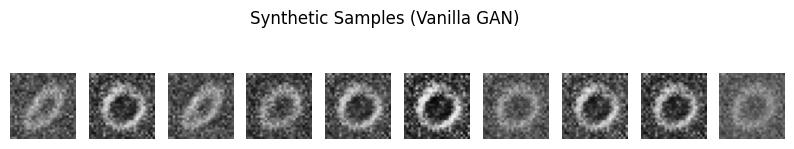

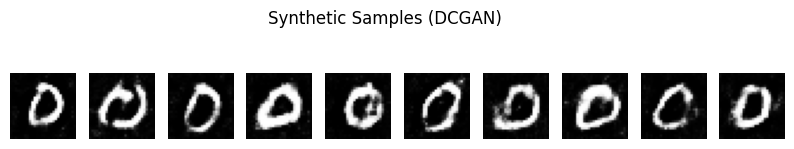

In [4]:
# Step 4: Generate & Visualize

# Calculate needed samples
counts = Counter(y_train_imbalanced.tolist())
needed = max(counts.values()) - counts[0]

# Generate function
def generate(G, n):
    G.eval()
    with torch.no_grad():
        z = torch.randn(n, 100).to(device)
        return G(z).cpu()

# Generate images
vanilla_fake = generate(vanilla_G, needed)
dc_fake = generate(dc_G, needed)

# Visualize with Contrast Fix
def show_samples(imgs, title):
    plt.figure(figsize=(10, 2))
    for i in range(10):
        plt.subplot(1, 10, i+1)

        # MATH FIX: Convert range [-1, 1] to [0, 1]
        # This prevents the "Gray/Static" look
        img = (imgs[i].squeeze() + 1) / 2

        plt.imshow(img, cmap='gray', vmin=0, vmax=1)
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

show_samples(vanilla_fake, "Synthetic Samples (Vanilla GAN)")
show_samples(dc_fake, "Synthetic Samples (DCGAN)")

# Step 5: Classification and Evaluation
We train a classifier (MLP) on three different scenarios to measure the impact of data augmentation:
1.  **Original Imbalanced:** The baseline performance.
2.  **Vanilla Balanced:** Augmented with Vanilla GAN data.
3.  **DCGAN Balanced:** Augmented with DCGAN data.

Finally, we compare **Accuracy** and **F1-Scores** to see which method worked best.

Training Classifier on Original Imbalanced...
Results: Accuracy=0.9514, F1=0.9514
Training Classifier on Vanilla GAN Balanced...
Results: Accuracy=0.9590, F1=0.9590
Training Classifier on DCGAN Balanced...
Results: Accuracy=0.9462, F1=0.9460

=== FINAL COMPARISON ===
      Scenario  Accuracy  F1 Score
0     Original    0.9514  0.951404
1  Vanilla GAN    0.9590  0.959021
2        DCGAN    0.9462  0.946017


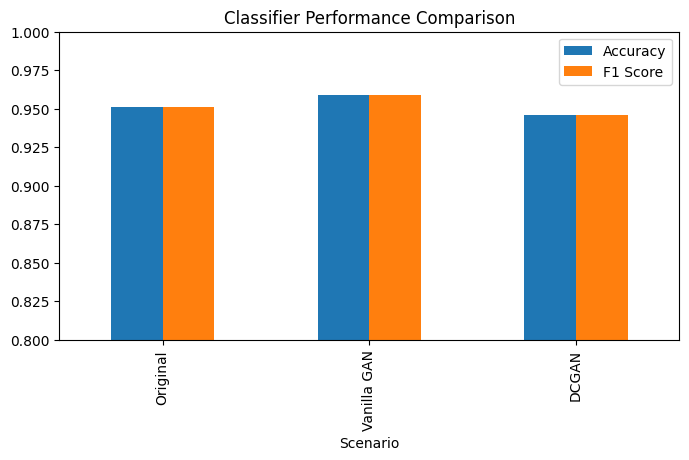


Classification Report (DCGAN Balanced):
              precision    recall  f1-score   support

           0       0.99      0.87      0.93       980
           1       0.96      0.99      0.98      1135
           2       0.94      0.97      0.96      1032
           3       0.94      0.95      0.95      1010
           4       0.94      0.96      0.95       982
           5       0.96      0.92      0.94       892
           6       0.93      0.97      0.95       958
           7       0.95      0.94      0.95      1028
           8       0.96      0.91      0.93       974
           9       0.90      0.96      0.93      1009

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



In [5]:
# Step 5: Classifier Evaluation

# 1. Prepare Datasets
# Normalize Original Data (0 to 1)
X_train_orig_norm = X_train_imbalanced.unsqueeze(1).float() / 255.0
X_test_norm = X_test.unsqueeze(1).float() / 255.0

# Prepare Synthetic Data (Rescale from -1..1 to 0..1)
vanilla_fake_norm = (vanilla_fake + 1) / 2
dc_fake_norm = (dc_fake + 1) / 2

# Create Labels for Synthetic Data (Digit 0)
y_fake = torch.zeros(len(vanilla_fake), dtype=torch.long)

# Create 3 Combined Datasets
# Scenario A: Original
ds_orig = TensorDataset(X_train_orig_norm, y_train_imbalanced)

# Scenario B: Balanced with Vanilla
X_vanilla = torch.cat([X_train_orig_norm, vanilla_fake_norm])
y_vanilla = torch.cat([y_train_imbalanced, y_fake])
ds_vanilla = TensorDataset(X_vanilla, y_vanilla)

# Scenario C: Balanced with DCGAN
X_dc = torch.cat([X_train_orig_norm, dc_fake_norm])
y_dc = torch.cat([y_train_imbalanced, y_fake])
ds_dc = TensorDataset(X_dc, y_dc)

# 2. Define Classifier (MLP)
class ClassifierMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.net(x)

# 3. Training Function
def train_and_eval(dataset, name):
    loader = DataLoader(dataset, batch_size=64, shuffle=True)
    model = ClassifierMLP().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    print(f"Training Classifier on {name}...")
    for epoch in range(2): # Train for 2 epochs
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            criterion(model(x), y).backward()
            optimizer.step()

    # Evaluation
    model.eval()
    all_preds = []
    with torch.no_grad():
        test_loader = DataLoader(TensorDataset(X_test_norm, y_test), batch_size=64)
        for x, _ in test_loader:
            all_preds.extend(model(x.to(device)).argmax(dim=1).cpu())

    acc = accuracy_score(y_test, all_preds)
    f1 = f1_score(y_test, all_preds, average='weighted')
    print(f"Results: Accuracy={acc:.4f}, F1={f1:.4f}")
    return acc, f1, all_preds

# 4. Run Experiments
acc_orig, f1_orig, preds_orig = train_and_eval(ds_orig, "Original Imbalanced")
acc_vanilla, f1_vanilla, preds_vanilla = train_and_eval(ds_vanilla, "Vanilla GAN Balanced")
acc_dc, f1_dc, preds_dc = train_and_eval(ds_dc, "DCGAN Balanced")

# 5. Compare Results
results = pd.DataFrame({
    'Scenario': ['Original', 'Vanilla GAN', 'DCGAN'],
    'Accuracy': [acc_orig, acc_vanilla, acc_dc],
    'F1 Score': [f1_orig, f1_vanilla, f1_dc]
})

print("\n=== FINAL COMPARISON ===")
print(results)

results.set_index('Scenario')[['Accuracy', 'F1 Score']].plot(kind='bar', figsize=(8, 4))
plt.title("Classifier Performance Comparison")
plt.ylim(0.8, 1.0)
plt.show()

print("\nClassification Report (DCGAN Balanced):")
print(classification_report(y_test, preds_dc))